In [151]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

 - RowNumber: The sequential number assigned to each row in the dataset.
 - CustomerId: A unique identifier for each customer.
 - Surname: The surname of the customer.
 - CreditScore: The credit score of the customer.
 - Geography: The geographical location of the customer (e.g., country or region).
 - Gender: The gender of the customer.
 - Age: The age of the customer.
 - Tenure: The number of years the customer has been with the bank.
 - Balance: The account balance of the customer.
 - NumOfProducts: The number of bank products the customer has.
 - HasCrCard: Indicates whether the customer has a credit card (binary: yes/no).
 - IsActiveMember: Indicates whether the customer is an active member (binary: yes/no).
 - EstimatedSalary: The estimated salary of the customer.
 - Exited: Indicates whether the customer has exited the bank (binary: yes/no).

In [152]:
df = pd.read_csv("Churn_Modelling.csv", delimiter=',')

df.head(10)

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
5,6,15574012,Chu,645,Spain,Male,44,8,113755.78,2,1,0,149756.71,1
6,7,15592531,Bartlett,822,France,Male,50,7,0.00,2,1,1,10062.80,0
7,8,15656148,Obinna,376,Germany,Female,29,4,115046.74,4,1,0,119346.88,1
8,9,15792365,He,501,France,Male,44,4,142051.07,2,0,1,74940.50,0
9,10,15592389,H?,684,France,Male,27,2,134603.88,1,1,1,71725.73,0


In [153]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [154]:
df['Geography'].unique()

<StringArray>
['France', 'Spain', 'Germany']
Length: 3, dtype: str

In [155]:
df['Gender'].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

In [156]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [157]:
sns.set_style('white')

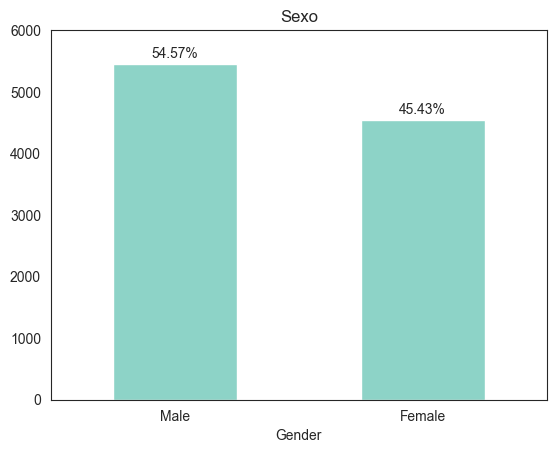

In [158]:
contagem = df['Gender'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')
ax.set_ylim(0, contagem.max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{p:.2f}%' for p in porcentagem], padding=2)

plt.title('Sexo')
plt.xlabel('Gender')
plt.xticks(rotation=0)
plt.show()

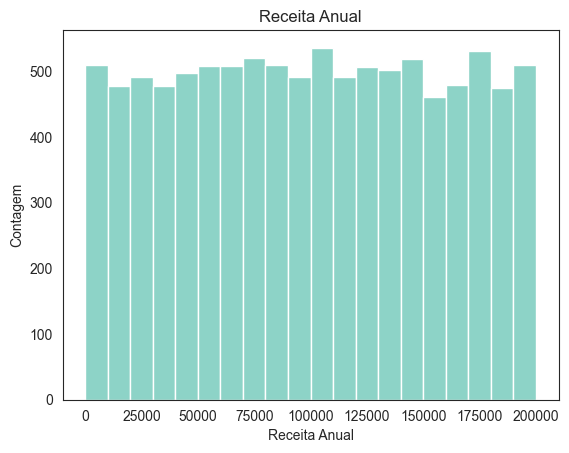

In [159]:
bins = np.arange(df['EstimatedSalary'].min(), df['EstimatedSalary'].max() + 10000, 10000)

ax = df['EstimatedSalary'].plot(kind='hist', bins=bins, edgecolor='white')
ax.set_xlabel('Receita Anual')
ax.set_ylabel('Contagem')
ax.set_title('Receita Anual')
plt.show()


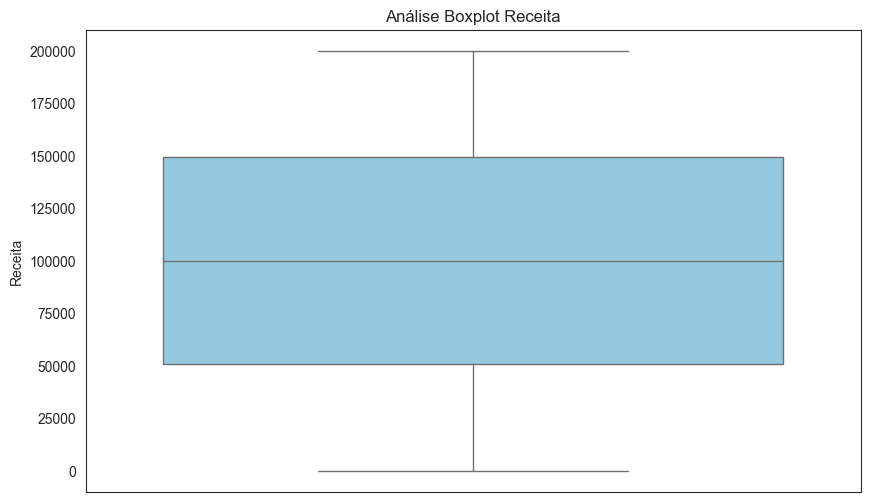

In [160]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y='EstimatedSalary', color='skyblue')
plt.title('Análise Boxplot Receita')
plt.ylabel('Receita')
plt.show()

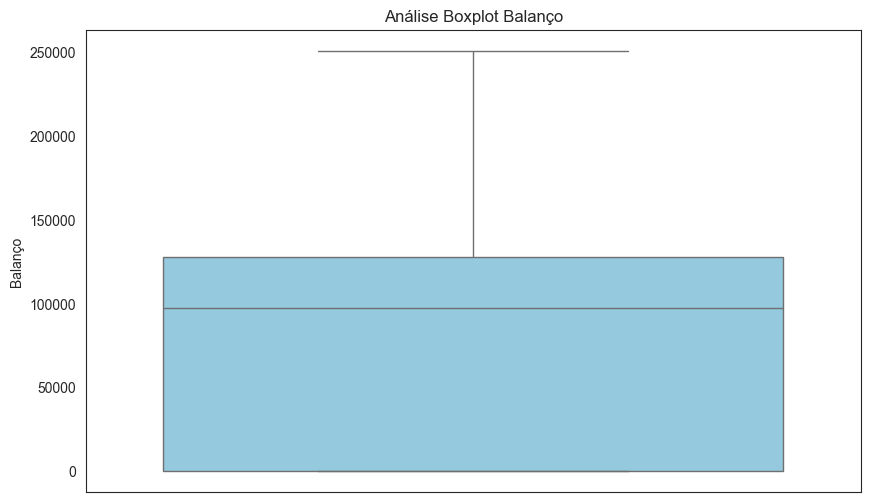

In [161]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y='Balance', color='skyblue')
plt.title('Análise Boxplot Balanço')
plt.ylabel('Balanço')
plt.show()

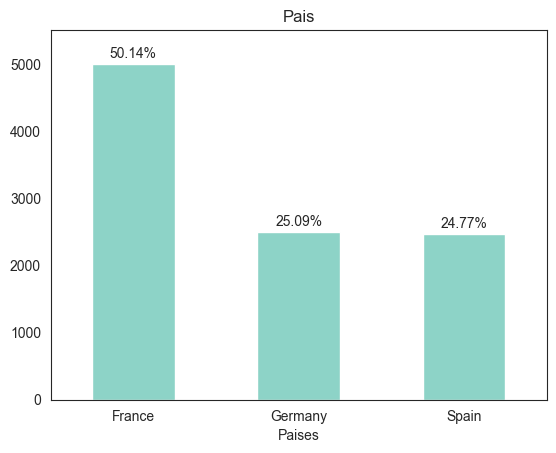

In [162]:
contagem = df['Geography'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')
ax.set_ylim(0, contagem.max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{p:.2f}%' for p in porcentagem], padding=2)

plt.title('Pais')
plt.xlabel('Paises')
plt.xticks(rotation=0)
plt.show()

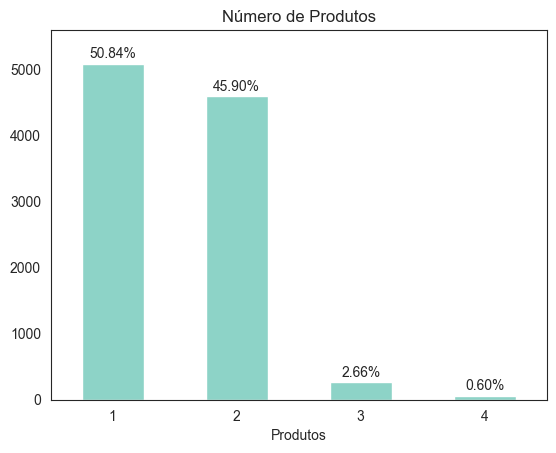

In [163]:
contagem = df['NumOfProducts'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')
ax.set_ylim(0, contagem.max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{p:.2f}%' for p in porcentagem], padding=2)

plt.title('Número de Produtos')
plt.xlabel('Produtos')
plt.xticks(rotation=0)
plt.show()

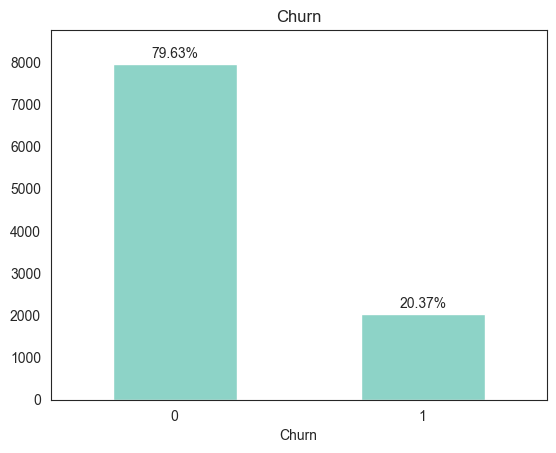

In [164]:
contagem = df['Exited'].value_counts()
porcentagem = (contagem / contagem.sum()) * 100

ax = contagem.plot(kind='bar')
ax.set_ylim(0, contagem.max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{p:.2f}%' for p in porcentagem], padding=2)

plt.title('Churn')
plt.xlabel('Churn')
plt.xticks(rotation=0)
plt.show()

## Churn: taxa por segmento

A seguir, os gráficos focam em **taxa de churn (%)** por grupos/faixas, que é a forma mais direta de comparar segmentos (evita o vi?s de contagem absoluta em bases desbalanceadas).


In [225]:
df_grouped = df.groupby(['Exited', 'Gender']).size().reset_index(name='count')
sexo_por_churn = df_grouped.groupby('Exited')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / sexo_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Exited', y='percent',
             color='Gender',
             barmode='stack',
             text=df_grouped['percent'].map(lambda v: f'{v:.1f}%'),
             labels={'Exited': 'Churn', 'percent': 'Porcentagem', 'Gender': 'Sexo'})

fig.update_layout(title='Relação entre Churn e Sexo',
                  yaxis_title='Porcentagem',
                  legend_title='Sexo')
fig.show()

In [226]:
bins = list(range(0, int(df['Tenure'].max()) + 2, 2))
labels = [f'{i}-{i + 2}' for i in bins[:-1]]
df['Tenure_Bins'] = pd.cut(df['Tenure'], bins=bins, labels=labels, include_lowest=True)

df_grouped = df.groupby(['Exited', 'Tenure_Bins']).size().reset_index(name='count')
sexo_por_churn = df_grouped.groupby('Exited')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / sexo_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Exited', y='percent',
             color='Tenure_Bins',
             barmode='stack',
             text=df_grouped['percent'].map(lambda v: f'{v:.1f}%'),
             labels={'Exited': 'Churn', 'percent': 'Porcentagem', 'Tenure_Bins': 'Tempo como Cliente'})

fig.update_layout(title='Relação entre Churn e Tempo como Cliente',
                  yaxis_title='Porcentagem',
                  legend_title='Tempo como Cliente')
fig.show()

In [230]:
bins = list(range(0, int(df['EstimatedSalary'].max()) + 50000, 50000))
labels = [f'{i}-{i + 50000}' for i in bins[:-1]]
df['EstimatedSalary_Bins'] = pd.cut(df['EstimatedSalary'], bins=bins, labels=labels, include_lowest=True)

df_grouped = df.groupby(['Exited', 'EstimatedSalary_Bins']).size().reset_index(name='count')
sexo_por_churn = df_grouped.groupby('Exited')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / sexo_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Exited', y='percent',
             color='EstimatedSalary_Bins',
             barmode='stack',
             text=df_grouped['percent'].map(lambda v: f'{v:.1f}%'),
             labels={'Exited': 'Churn', 'percent': 'Porcentagem', 'EstimatedSalary_Bins': 'Receita'})

fig.update_layout(title='Relação entre Churn e Receita',
                  yaxis_title='Porcentagem',
                  legend_title='Receita')
fig.show()

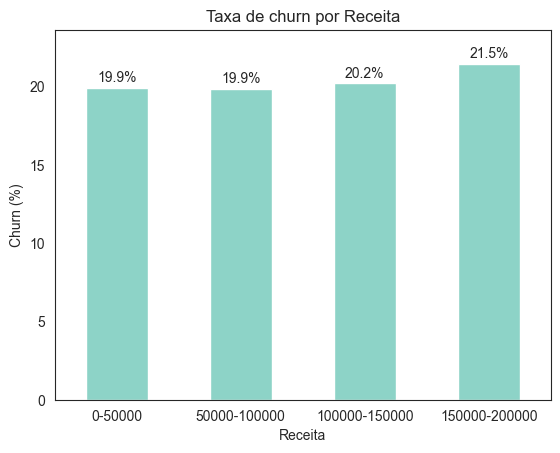

In [232]:
df_rate = df.groupby('EstimatedSalary_Bins')['Exited'].mean().reset_index(name='churn_rate')
df_rate['churn_rate'] = df_rate['churn_rate'] * 100

ax = df_rate.plot(kind='bar', x='EstimatedSalary_Bins', y='churn_rate', legend=False)
ax.set_ylim(0, df_rate['churn_rate'].max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in df_rate['churn_rate']], padding=2)
plt.title('Taxa de churn por Receita')
plt.xlabel('Receita')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)
plt.show()

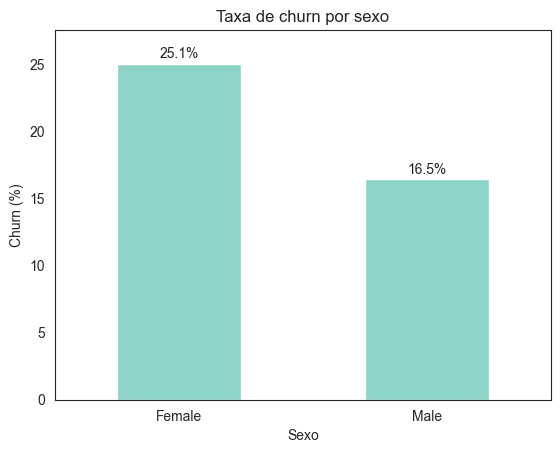

In [217]:
df_rate = df.groupby('Gender')['Exited'].mean().reset_index(name='churn_rate')
df_rate['churn_rate'] = df_rate['churn_rate'] * 100

ax = df_rate.plot(kind='bar', x='Gender', y='churn_rate', legend=False)
ax.set_ylim(0, df_rate['churn_rate'].max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in df_rate['churn_rate']], padding=2)
plt.title('Taxa de churn por sexo')
plt.xlabel('Sexo')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)
plt.show()

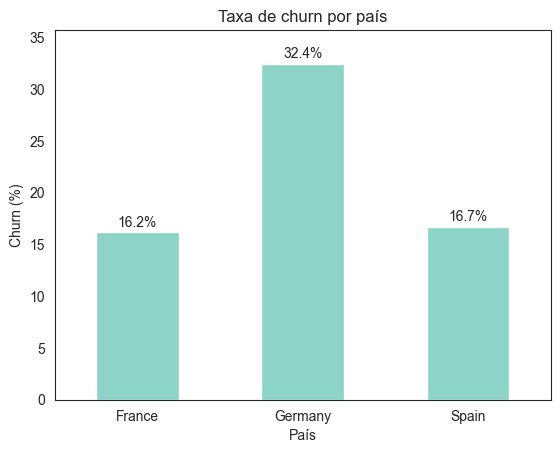

In [219]:
df_rate = df.groupby('Geography')['Exited'].mean().reset_index(name='churn_rate')
df_rate['churn_rate'] = df_rate['churn_rate'] * 100

ax = df_rate.plot(kind='bar', x='Geography', y='churn_rate', legend=False)
ax.set_ylim(0, df_rate['churn_rate'].max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in df_rate['churn_rate']], padding=2)
plt.title('Taxa de churn por país')
plt.xlabel('País')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)
plt.show()

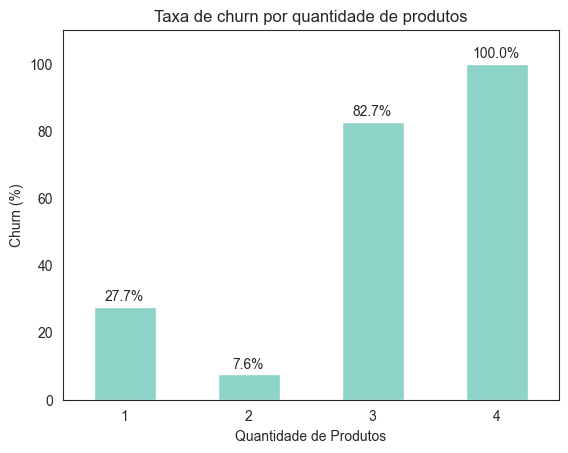

In [221]:
df_rate = df.groupby('NumOfProducts')['Exited'].mean().reset_index(name='churn_rate')
df_rate['churn_rate'] = df_rate['churn_rate'] * 100

ax = df_rate.plot(kind='bar', x='NumOfProducts', y='churn_rate', legend=False)
ax.set_ylim(0, df_rate['churn_rate'].max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in df_rate['churn_rate']], padding=2)
plt.title('Taxa de churn por quantidade de produtos')
plt.xlabel('Quantidade de Produtos')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)
plt.show()

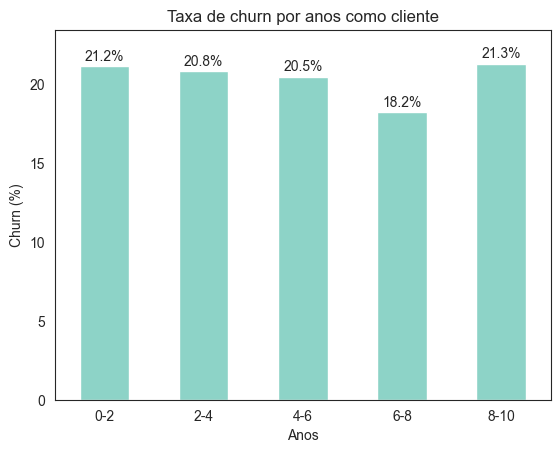

In [223]:
df_rate = df.groupby('Tenure_Bins')['Exited'].mean().reset_index(name='churn_rate')
df_rate['churn_rate'] = df_rate['churn_rate'] * 100

ax = df_rate.plot(kind='bar', x='Tenure_Bins', y='churn_rate', legend=False)
ax.set_ylim(0, df_rate['churn_rate'].max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in df_rate['churn_rate']], padding=2)
plt.title('Taxa de churn por anos como cliente')
plt.xlabel('Anos')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)
plt.show()

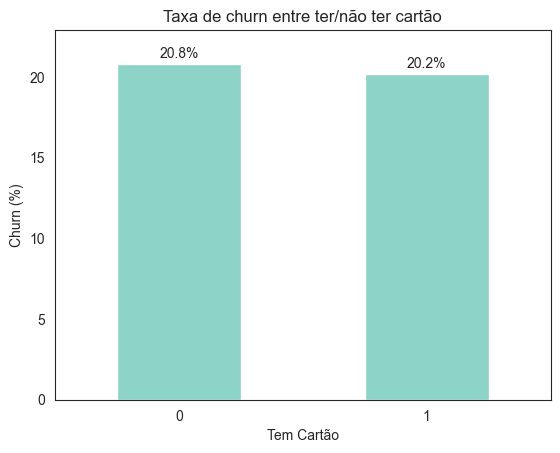

In [234]:
df_rate = df.groupby('HasCrCard')['Exited'].mean().reset_index(name='churn_rate')
df_rate['churn_rate'] = df_rate['churn_rate'] * 100

ax = df_rate.plot(kind='bar', x='HasCrCard', y='churn_rate', legend=False)
ax.set_ylim(0, df_rate['churn_rate'].max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in df_rate['churn_rate']], padding=2)
plt.title('Taxa de churn entre ter/não ter cartão')
plt.xlabel('Tem Cartão')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)
plt.show()

In [241]:
bins = list(range(0, int(df['CreditScore'].max()) + 100, 100))
labels = [f'{i}-{i + 100}' for i in bins[:-1]]
df['CreditScore_Bins'] = pd.cut(df['CreditScore'], bins=bins, labels=labels, include_lowest=True)

df_grouped = df.groupby(['Exited', 'CreditScore_Bins']).size().reset_index(name='count')
sexo_por_churn = df_grouped.groupby('Exited')['count'].transform('sum')
df_grouped['percent'] = (df_grouped['count'] / sexo_por_churn) * 100

# Cria gráfico de barras empilhadas
fig = px.bar(df_grouped, x='Exited', y='percent',
             color='CreditScore_Bins',
             barmode='stack',
             text=df_grouped['percent'].map(lambda v: f'{v:.1f}%'),
             labels={'Exited': 'Churn', 'percent': 'Porcentagem', 'CreditScore_Bins': 'Score'},
             category_orders={'CreditScore_Bins': labels, 'Exited':[0, 1]})

fig.update_layout(title='Relação entre Churn e Score',
                  yaxis_title='Porcentagem',
                  legend_title='Score')
fig.show()

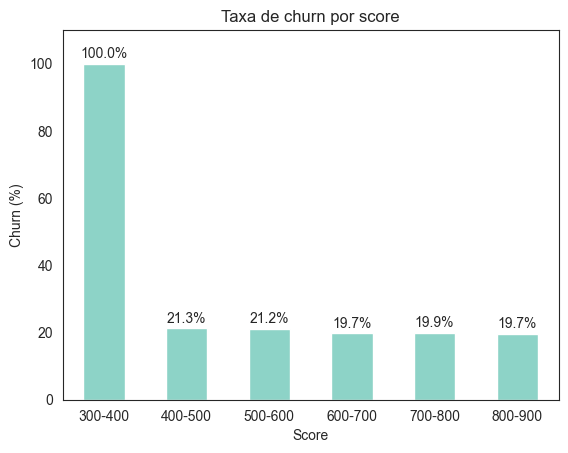

In [246]:
df_rate = df.groupby('CreditScore_Bins')['Exited'].mean().reset_index(name='churn_rate')
df_rate['churn_rate'] = df_rate['churn_rate'] * 100

ax = df_rate.plot(kind='bar', x='CreditScore_Bins', y='churn_rate', legend=False)
ax.set_ylim(0, df_rate['churn_rate'].max() * 1.1)
ax.bar_label(ax.containers[0], labels=[f'{v:.1f}%' for v in df_rate['churn_rate']], padding=2)
plt.title('Taxa de churn por score')
plt.xlabel('Score')
plt.ylabel('Churn (%)')
plt.xticks(rotation=0)
plt.show()

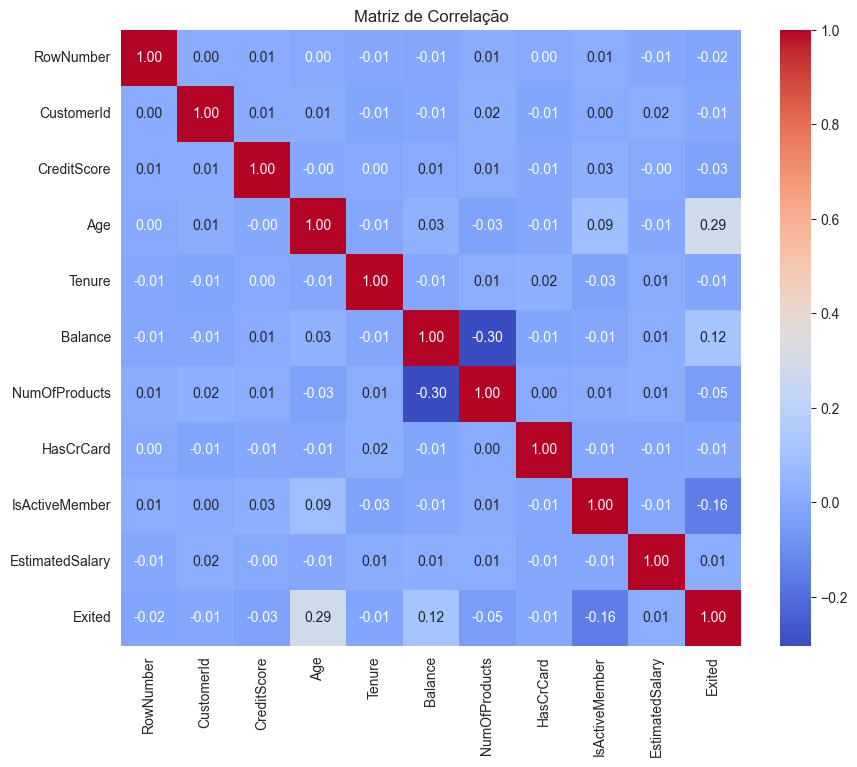

In [248]:
correlation_matrix = df.select_dtypes(include=['number']).corr()

# Plotar o mapa de calor da matriz de correlação
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", annot_kws={"size": 10})
plt.title('Matriz de Correlação')
plt.show()

Os dados no geral, não mostram relação clara e forte entre as variáveis. Renda, por exemplo, existe uma tendência de que clientes com renda mais alta tenham uma taxa de churn maior, essa relação não é estatisticamente significativa. Além disso, a idade dos clientes também tem moderada relação com o churn., a maioria dos clientes que churnam são entre 35 e 60 anos. As variáveis com maior correlação tem valores pequenos, também. O pulo mais significativo é entre 2 e 3 produtos adquiridos, a maioria dos que passam a ter 3 produtos acabam em churn e todos os com 4. Scores abaixo de 400 resultado em 100% de churn, também.
